<a href="https://colab.research.google.com/github/predicting-pregnancy-success/pregnancy-ml-models/blob/main/%EB%82%9C%EC%9E%84_%ED%99%98%EC%9E%90_%EB%8C%80%EC%83%81_%EC%9E%84%EC%8B%A0_%EC%84%B1%EA%B3%B5_%EC%97%AC%EB%B6%80_%EC%98%88%EC%B8%A1AI_v2-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 폰트 설치
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 78.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import random
import os

from sklearn.preprocessing import LabelEncoder

import koreanize_matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

In [3]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

seed_everything(42) # Seed 고정

In [6]:
# 1. 테스트 로드

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

display(train.head())

,ID,시술 시기 코드,시술 당시 나이,임신 시도 또는 마지막 임신 경과 연수,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,...,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
0,TRAIN_000000,TRZKPL,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0
1,TRAIN_000001,TRYBLT,만45-50세,NaN,IVF,ICSI,0,알 수 없음,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
2,TRAIN_000002,TRVNRY,만18-34세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,2.0,NaN,0
3,TRAIN_000003,TRJXFG,만35-37세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
4,TRAIN_000004,TRVNRY,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0


In [7]:
# 전체 데이터 확인

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256351 entries, 0 to 256350
Data columns (total 69 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     256351 non-null  object 
 1   시술 시기 코드               256351 non-null  object 
 2   시술 당시 나이               256351 non-null  object 
 3   임신 시도 또는 마지막 임신 경과 연수  9370 non-null    float64
 4   시술 유형                  256351 non-null  object 
 5   특정 시술 유형               256349 non-null  object 
 6   배란 자극 여부               256351 non-null  int64  
 7   배란 유도 유형               256351 non-null  object 
 8   단일 배아 이식 여부            250060 non-null  float64
 9   착상 전 유전 검사 사용 여부       2718 non-null    float64
 10  착상 전 유전 진단 사용 여부       250060 non-null  float64
 11  남성 주 불임 원인             256351 non-null  int64  
 12  남성 부 불임 원인             256351 non-null  int64  
 13  여성 주 불임 원인             256351 non-null  int64  
 14  여성 부 불임 원인             256351 non-nu

In [8]:
train.isnull().sum()

,0
ID,0
시술 시기 코드,0
시술 당시 나이,0
임신 시도 또는 마지막 임신 경과 연수,246981
시술 유형,0
...,...
난자 해동 경과일,254915
난자 혼합 경과일,53735
배아 이식 경과일,43566
배아 해동 경과일,215982


In [9]:
train.describe()

,임신 시도 또는 마지막 임신 경과 연수,배란 자극 여부,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,착상 전 유전 진단 사용 여부,남성 주 불임 원인,남성 부 불임 원인,여성 주 불임 원인,여성 부 불임 원인,부부 주 불임 원인,...,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
count,9370.000000,256351.000000,250060.000000,2718.0,250060.000000,256351.000000,256351.000000,256351.000000,256351.000000,256351.000000,...,250060.000000,250060.000000,2179.0,1929.0,198863.0,1436.000000,202616.000000,212785.000000,40369.000000,256351.000000
mean,9.270651,0.771286,0.233476,1.0,0.012781,0.028516,0.013115,0.030724,0.012432,0.033068,...,0.009830,0.004195,1.0,1.0,0.0,0.001393,0.005385,3.254741,0.045629,0.258349
std,3.550313,0.420005,0.423043,0.0,0.112328,0.166441,0.113767,0.172568,0.110805,0.178814,...,0.098656,0.064633,0.0,0.0,0.0,0.037307,0.111504,1.715697,0.418672,0.437728
min,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.0,1.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,1.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.0,1.0,0.0,0.000000,0.000000,2.000000,0.000000,0.000000
50%,9.000000,1.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.0,1.0,0.0,0.000000,0.000000,3.000000,0.000000,0.000000
75%,11.000000,1.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.0,1.0,0.0,0.000000,0.000000,5.000000,0.000000,1.000000
max,20.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.0,1.0,0.0,1.000000,7.000000,7.000000,7.000000,1.000000


In [10]:
# 결측치 처리
train_copy = train.copy()
test_copy = test.copy()

# '임신 성공 여부' 결측치 행만 찾아서 삭제하기
train_copy = train_copy.dropna(subset=['임신 성공 여부'])

# 결측치가 많은 컬럼 삭제하기
train_copy = train_copy.drop(columns=['임신 시도 또는 마지막 임신 경과 연수'])
test_copy = test_copy.drop(columns=['임신 시도 또는 마지막 임신 경과 연수'])

# 결측 지시 변수 컬럼
very_high_missing = [
        '착상 전 유전 검사 사용 여부',
        'PGD 시술 여부',
        'PGS 시술 여부',
        '난자 해동 경과일',
        '난자 채취 경과일',
        '난자 혼합 경과일',
        '배아 이식 경과일',
        '배아 해동 경과일',
    ]
for col in very_high_missing:
    train_copy[f'{col}_missing'] = train_copy[col].isnull().astype(int)
    test_copy[f'{col}_missing'] = test_copy[col].isnull().astype(int)
    train_copy[col] = train_copy[col].fillna(0)
    test_copy[col] = test_copy[col].fillna(0)

# 결측치를 'Unknown'으로 채울 컬럼 리스트
object_cols = [
    '특정 시술 유형', '배아 생성 주요 이유', '총 시술 횟수', '클리닉 내 총 시술 횟수',
    'IVF 시술 횟수', 'DI 시술 횟수', '총 임신 횟수', 'IVF 임신 횟수', 'DI 임신 횟수',
    '총 출산 횟수', 'IVF 출산 횟수', 'DI 출산 횟수', '난자 출처', '정자 출처',
    '난자 기증자 나이', '정자 기증자 나이'
]

# Unknown으로 채우기
train_copy[object_cols] = train_copy[object_cols].fillna('Unknown')
test_copy[object_cols] = test_copy[object_cols].fillna('Unknown')

# 결측치를 0으로 채울 숫자형(float/int) 컬럼 리스트
number_cols = [
    '단일 배아 이식 여부', '착상 전 유전 진단 사용 여부',
    '불임 원인 - 정자 운동성', '불임 원인 - 정자 형태', '총 생성 배아 수',
    '미세주입된 난자 수', '미세주입에서 생성된 배아 수', '이식된 배아 수',
    '미세주입 배아 이식 수', '저장된 배아 수', '미세주입 후 저장된 배아 수',
    '해동된 배아 수', '해동 난자 수', '수집된 신선 난자 수', '저장된 신선 난자 수',
    '혼합된 난자 수', '파트너 정자와 혼합된 난자 수', '기증자 정자와 혼합된 난자 수',
    '동결 배아 사용 여부', '신선 배아 사용 여부', '기증 배아 사용 여부',
    '대리모 여부'
]

# 0으로 채우기
train_copy[number_cols] = train_copy[number_cols].fillna(0)
test_copy[number_cols] = test_copy[number_cols].fillna(0)

In [11]:
# 결측치 처리 후 확인
print(train_copy.isnull().sum().sum())
print(test_copy.isnull().sum().sum())

train_copy.info()

0
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256351 entries, 0 to 256350
Data columns (total 76 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        256351 non-null  object 
 1   시술 시기 코드                  256351 non-null  object 
 2   시술 당시 나이                  256351 non-null  object 
 3   시술 유형                     256351 non-null  object 
 4   특정 시술 유형                  256351 non-null  object 
 5   배란 자극 여부                  256351 non-null  int64  
 6   배란 유도 유형                  256351 non-null  object 
 7   단일 배아 이식 여부               256351 non-null  float64
 8   착상 전 유전 검사 사용 여부          256351 non-null  float64
 9   착상 전 유전 진단 사용 여부          256351 non-null  float64
 10  남성 주 불임 원인                256351 non-null  int64  
 11  남성 부 불임 원인                256351 non-null  int64  
 12  여성 주 불임 원인                256351 non-null  int64  
 13  여성 부 불임 원인                256351 non-nul

In [12]:
# 인코딩

# 시술 당시 나이 구간
age_map = {
    '만18-34세': 0, '만35-37세': 1, '만38-39세': 2,
    '만40-42세': 3, '만43-44세': 4, '만45-50세': 5,
    '알 수 없음': -1, 'Unknown': -1
}

# 시술 당시 나이 맵핑
train_copy['시술 당시 나이'] = train_copy['시술 당시 나이'].map(age_map)
test_copy['시술 당시 나이'] = test_copy['시술 당시 나이'].map(age_map)


# 기증자 나이 구간
donor_map = {
    '만20세 이하': 0, '만21-25세': 1, '만26-30세': 2,
    '만31-35세': 3, '만36-40세': 4, '만41-45세': 5,
    '알 수 없음': -1, 'Unknown': -1
}

# 기증자 나이 맵핑 (난자, 정자 둘 다)
for col in ['난자 기증자 나이', '정자 기증자 나이']:
    train_copy[col] = train_copy[col].map(donor_map)
    test_copy[col] = test_copy[col].map(donor_map)


# 횟수 구간 (0회 ~ 6회 이상)
count_map = {
    '0회': 0, '1회': 1, '2회': 2, '3회': 3,
    '4회': 4, '5회': 5, '6회 이상': 6,
    'Unknown': -1
}

# 횟수와 관련된 컬럼들 리스트
count_cols = [
    '총 시술 횟수', '클리닉 내 총 시술 횟수', 'IVF 시술 횟수', 'DI 시술 횟수',
    '총 임신 횟수', 'IVF 임신 횟수', 'DI 임신 횟수',
    '총 출산 횟수', 'IVF 출산 횟수', 'DI 출산 횟수'
]

# 횟수 관련 모든 컬럼 맵핑
for col in count_cols:
    train_copy[col] = train_copy[col].map(count_map)
    test_copy[col] = test_copy[col].map(count_map)


In [13]:
# 명목형 인코딩
nominal_cols = [
    '시술 시기 코드', '시술 유형', '특정 시술 유형',
    '배란 유도 유형', '배아 생성 주요 이유',
    '난자 출처', '정자 출처',
]

for col in nominal_cols:
    le = LabelEncoder()

    # 문자열로 통일
    train_copy[col] = train_copy[col].astype(str)
    test_copy[col] = test_copy[col].astype(str)

    # train에 있는 글자 종류를 파악
    train_labels = set(train_copy[col].unique())

    # test에만 있는 글자는 'Unknown'으로 대체
    test_copy[col] = test_copy[col].apply(lambda x: x if x in train_labels else 'Unknown')

    le.fit(list(train_labels) + ['Unknown'])

    # 숫자로 변환
    train_copy[col] = le.transform(train_copy[col])
    test_copy[col] = le.transform(test_copy[col])

In [14]:
train_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256351 entries, 0 to 256350
Data columns (total 76 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        256351 non-null  object 
 1   시술 시기 코드                  256351 non-null  int64  
 2   시술 당시 나이                  256351 non-null  int64  
 3   시술 유형                     256351 non-null  int64  
 4   특정 시술 유형                  256351 non-null  int64  
 5   배란 자극 여부                  256351 non-null  int64  
 6   배란 유도 유형                  256351 non-null  int64  
 7   단일 배아 이식 여부               256351 non-null  float64
 8   착상 전 유전 검사 사용 여부          256351 non-null  float64
 9   착상 전 유전 진단 사용 여부          256351 non-null  float64
 10  남성 주 불임 원인                256351 non-null  int64  
 11  남성 부 불임 원인                256351 non-null  int64  
 12  여성 주 불임 원인                256351 non-null  int64  
 13  여성 부 불임 원인                256351 non-null  i

In [15]:
TARGET = '임신 성공 여부'
BASELINE = train_copy[TARGET].mean()  # 전체 평균 성공률
print(f"전체 성공률 (베이스라인): {BASELINE:.3f}")

전체 성공률 (베이스라인): 0.258


In [16]:
# 시각화
sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

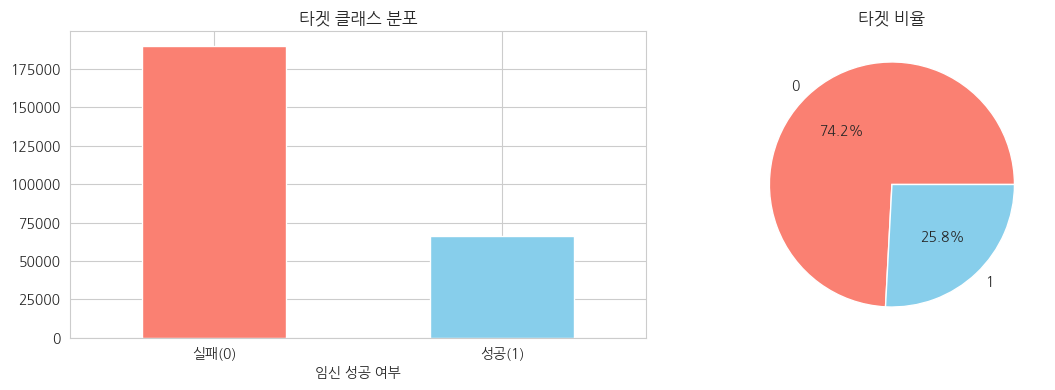

In [15]:
# 임신 성공 여부
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 클래스 분포
train_copy[TARGET].value_counts().plot(kind='bar', ax=axes[0], color=['salmon', 'skyblue'])
axes[0].set_title('타겟 클래스 분포')
axes[0].set_xticklabels(['실패(0)', '성공(1)'], rotation=0)

# 비율
train_copy[TARGET].value_counts(normalize=True).plot(kind='pie', ax=axes[1],
                                                      autopct='%.1f%%', colors=['salmon', 'skyblue'])
axes[1].set_title('타겟 비율')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

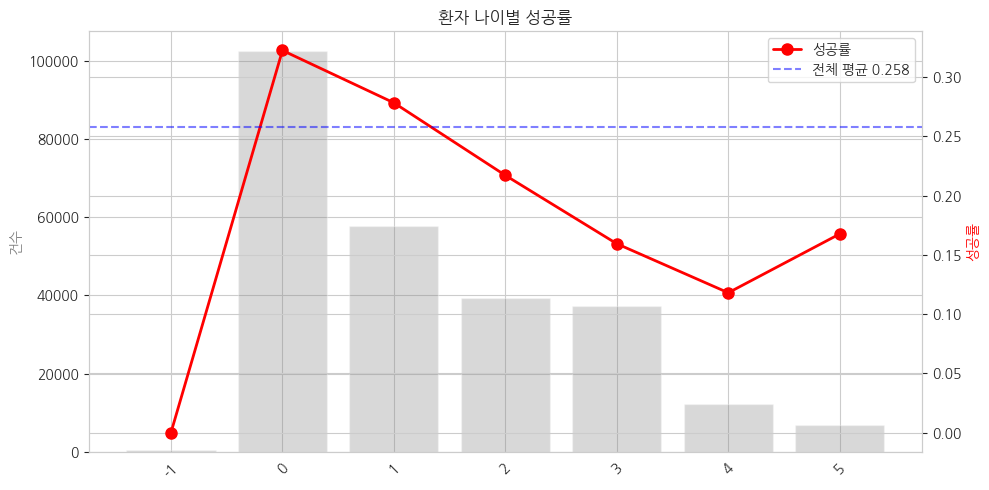

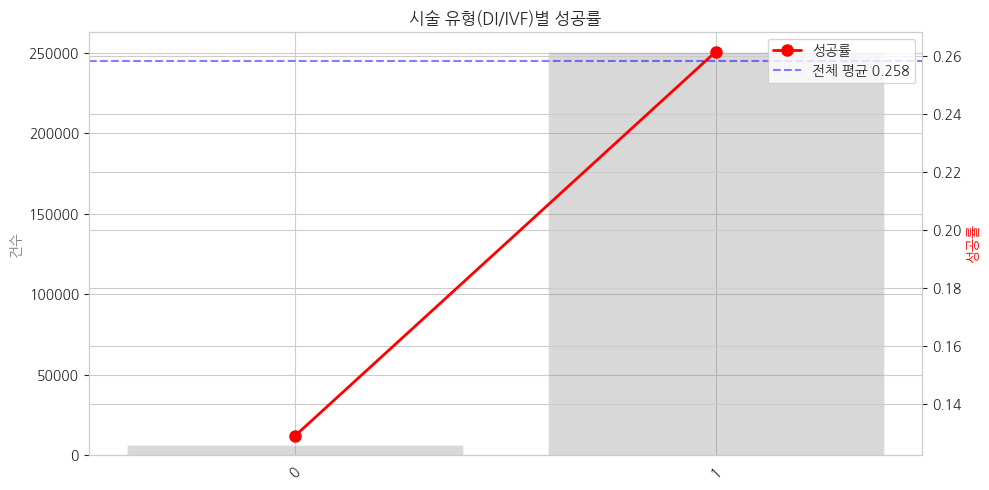

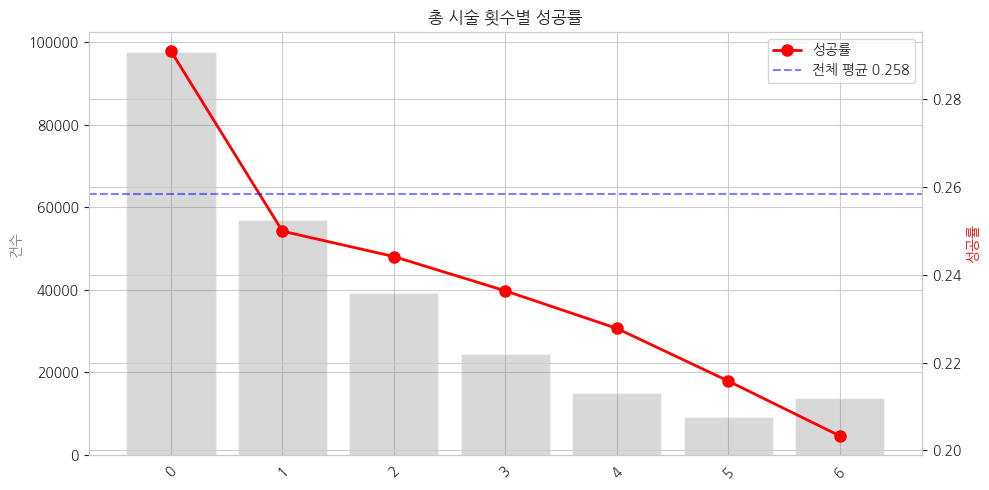

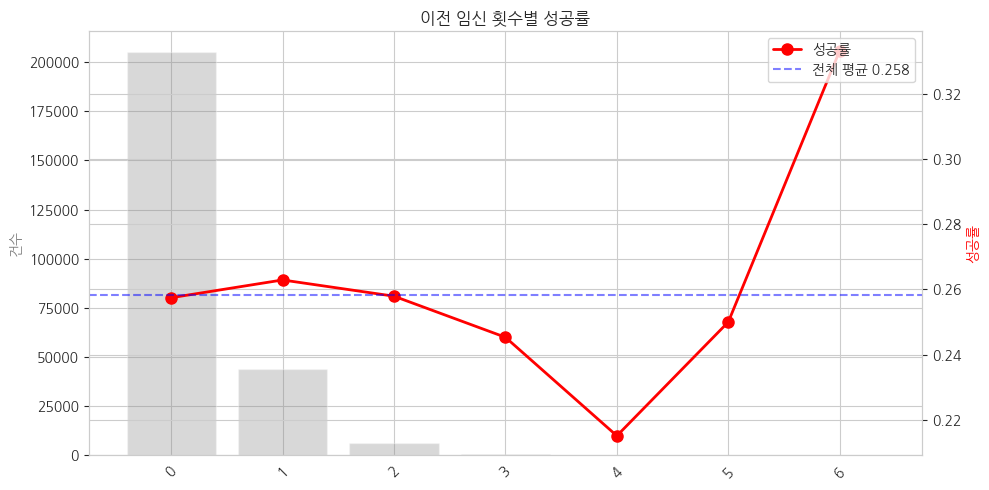

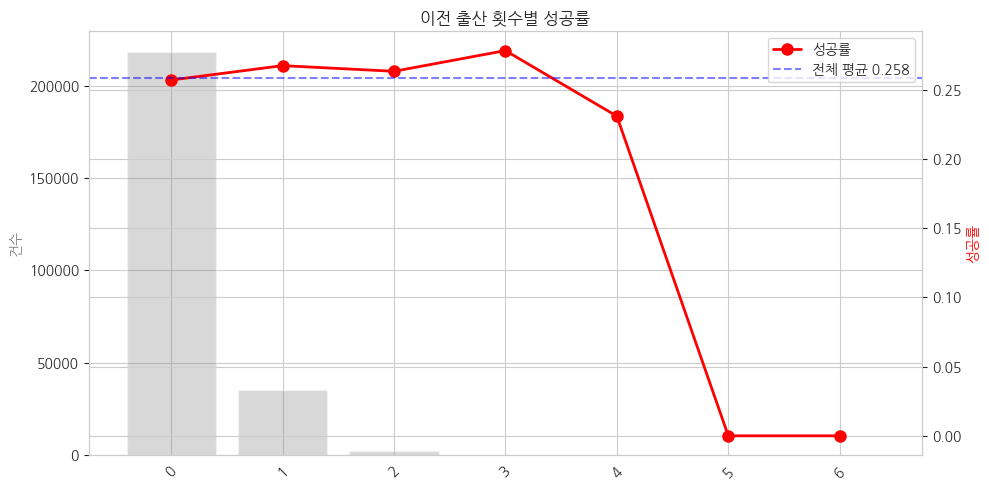

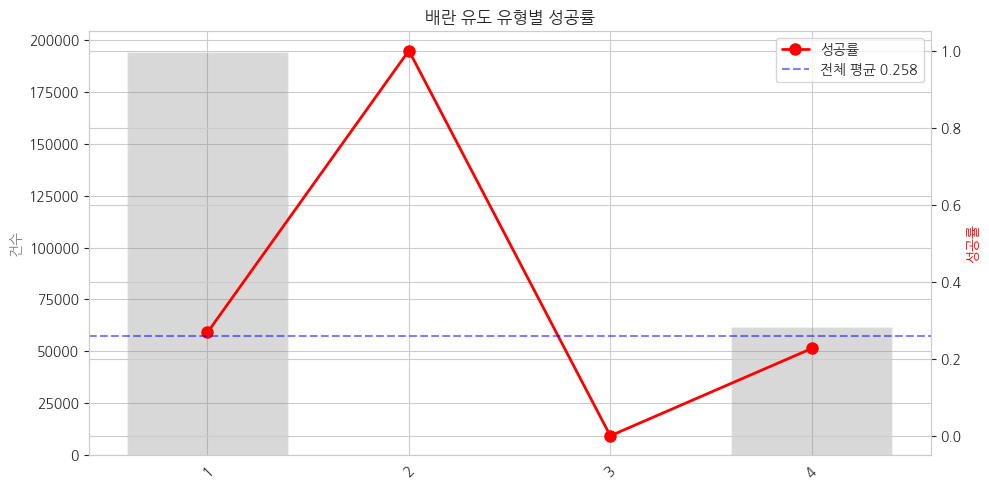

In [16]:
def plot_success_rate(col, title=None, figsize=(10, 5)):
    """카테고리별 성공률을 시각화"""
    grouped = train_copy.groupby(col)[TARGET].agg(['mean', 'count']).reset_index()

    fig, ax1 = plt.subplots(figsize=figsize)

    # 막대: 건수
    ax1.bar(grouped[col].astype(str), grouped['count'], alpha=0.3, color='gray', label='건수')
    ax1.set_ylabel('건수', color='gray')
    ax1.tick_params(axis='x', rotation=45)

    # 선: 성공률
    ax2 = ax1.twinx()
    ax2.plot(grouped[col].astype(str), grouped['mean'], 'o-', color='red', linewidth=2, markersize=8, label='성공률')
    ax2.axhline(BASELINE, color='blue', linestyle='--', alpha=0.5, label=f'전체 평균 {BASELINE:.3f}')
    ax2.set_ylabel('성공률', color='red')
    ax2.legend(loc='upper right')

    plt.title(title or f'{col}별 성공률')
    plt.tight_layout()
    plt.show()

# 핵심 변수들
plot_success_rate('시술 당시 나이', '환자 나이별 성공률')
plot_success_rate('시술 유형', '시술 유형(DI/IVF)별 성공률')
plot_success_rate('총 시술 횟수', '총 시술 횟수별 성공률')
plot_success_rate('총 임신 횟수', '이전 임신 횟수별 성공률')
plot_success_rate('총 출산 횟수', '이전 출산 횟수별 성공률')
plot_success_rate('배란 유도 유형', '배란 유도 유형별 성공률')

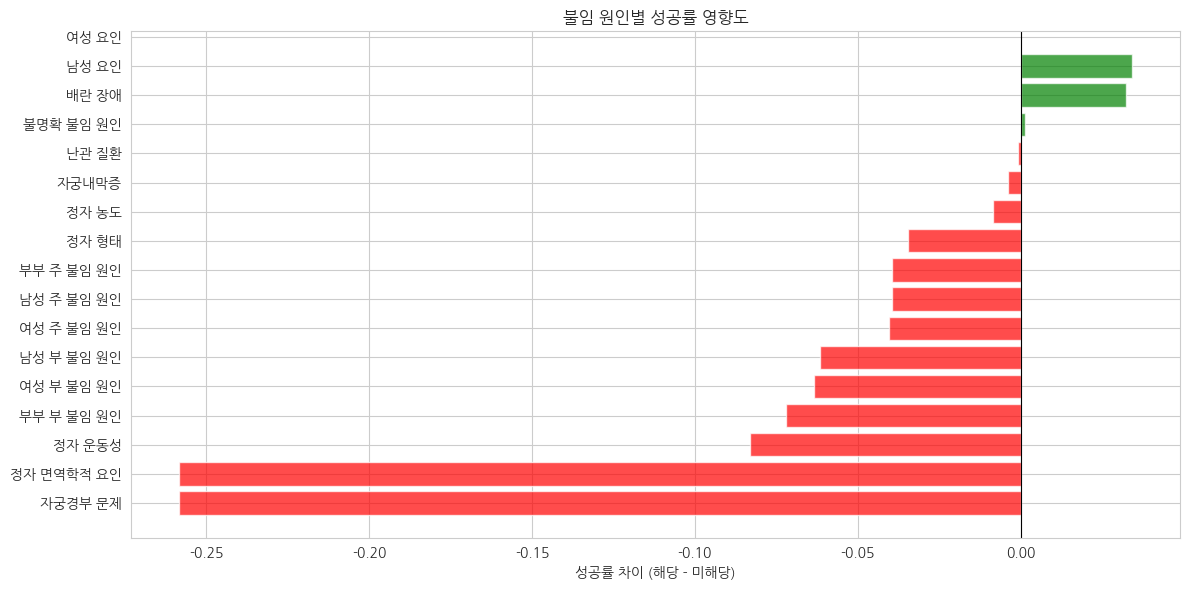

        원인   해당_성공률  미해당_성공률        차이  해당건수
   자궁경부 문제 0.000000 0.258359 -0.258359    10
정자 면역학적 요인 0.000000 0.258350 -0.258350     1
    정자 운동성 0.175258 0.258380 -0.083123    97
부부 부 불임 원인 0.186916 0.258981 -0.072065  2247
여성 부 불임 원인 0.195795 0.259136 -0.063341  3187
남성 부 불임 원인 0.197501 0.259158 -0.061656  3362
여성 주 불임 원인 0.219147 0.259592 -0.040445  7876
남성 주 불임 원인 0.219973 0.259475 -0.039503  7310
부부 주 불임 원인 0.220243 0.259652 -0.039409  8477
     정자 형태 0.223776 0.258368 -0.034592   143
     정자 농도 0.250000 0.258358 -0.008358   276
     자궁내막증 0.254836 0.258619 -0.003783 18302
     난관 질환 0.257755 0.258445 -0.000689 35557
 불명확 불임 원인 0.259463 0.257976  0.001487 64275
     배란 장애 0.286633 0.254108  0.032525 33426
     남성 요인 0.279890 0.245567  0.034324 95466
     여성 요인      NaN 0.258349       NaN     0


In [17]:
# 불임 원인 이진 컬럼 12개
infertility_cols = [col for col in train_copy.columns if '불임 원인' in col or '부부 주' in col or '부부 부' in col or '남성 주' in col or '남성 부' in col or '여성 주' in col or '여성 부' in col or '불명확' in col]

fig, ax = plt.subplots(figsize=(12, 6))
success_by_cause = []
for col in infertility_cols:
    rate_1 = train_copy.loc[train_copy[col] == 1, TARGET].mean()
    rate_0 = train_copy.loc[train_copy[col] == 0, TARGET].mean()
    count_1 = (train_copy[col] == 1).sum()
    success_by_cause.append({
        '원인': col.replace('불임 원인 - ', ''),
        '해당_성공률': rate_1,
        '미해당_성공률': rate_0,
        '차이': rate_1 - rate_0,
        '해당건수': count_1
    })

cause_df = pd.DataFrame(success_by_cause).sort_values('차이')
colors = ['red' if x < 0 else 'green' for x in cause_df['차이']]
ax.barh(cause_df['원인'], cause_df['차이'], color=colors, alpha=0.7)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('성공률 차이 (해당 - 미해당)')
ax.set_title('불임 원인별 성공률 영향도')
plt.tight_layout()
plt.show()

print(cause_df.to_string(index=False))

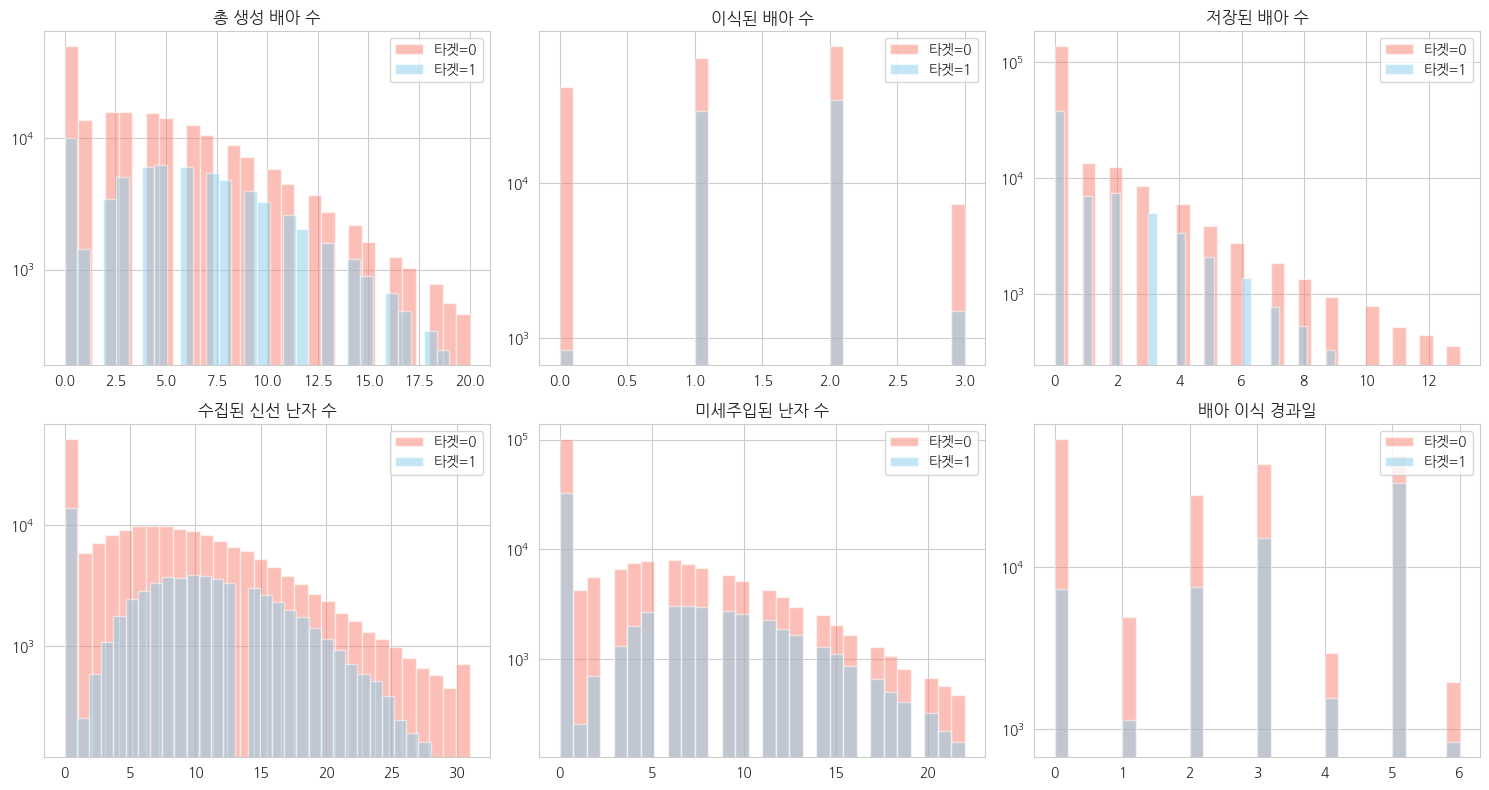

In [18]:
numeric_key_cols = [
    '총 생성 배아 수', '이식된 배아 수', '저장된 배아 수',
    '수집된 신선 난자 수', '미세주입된 난자 수',
    '배아 이식 경과일',
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(numeric_key_cols):
    ax = axes[i//3, i%3]
    for target_val, color in [(0, 'salmon'), (1, 'skyblue')]:
        data = train_copy.loc[train_copy[TARGET] == target_val, col]
        # 극단값 제거 (상위 1% 이상은 제외)
        upper = data.quantile(0.99)
        data = data[data <= upper]
        ax.hist(data, bins=30, alpha=0.5, label=f'타겟={int(target_val)}', color=color)
    ax.set_title(col)
    ax.legend()
    ax.set_yscale('log')  # 분포가 치우쳐 있으므로 로그 스케일

plt.tight_layout()
plt.show()

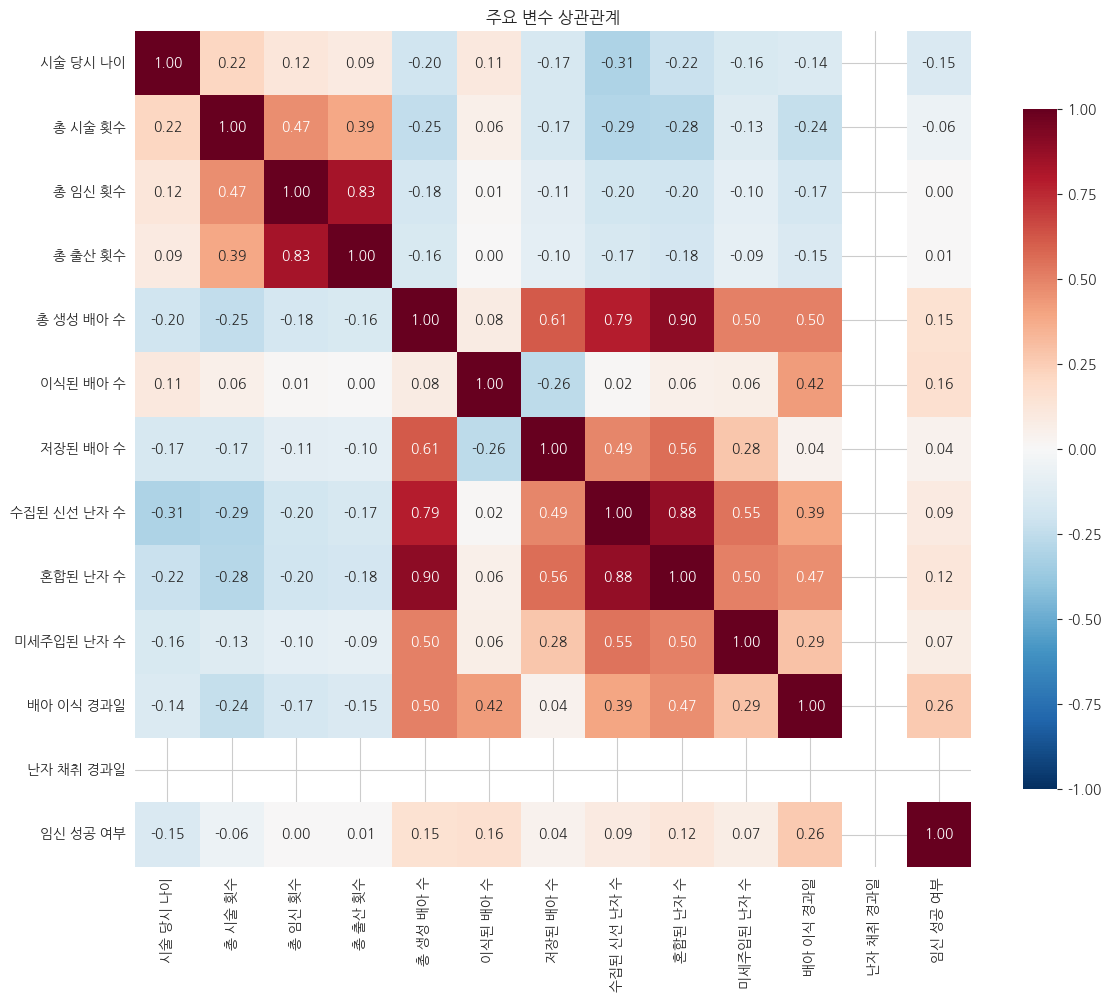

타겟과의 상관계수 절댓값 Top 10:
배아 이식 경과일      0.261680
이식된 배아 수       0.163030
총 생성 배아 수      0.150710
시술 당시 나이       0.148657
혼합된 난자 수       0.121826
수집된 신선 난자 수    0.089440
미세주입된 난자 수     0.074479
총 시술 횟수        0.058923
저장된 배아 수       0.039099
총 출산 횟수        0.007696
Name: 임신 성공 여부, dtype: float64


In [19]:
# 수치형 변수만 선택 (너무 많으면 읽기 어려우므로 주요 변수만)
key_numeric = [
    '시술 당시 나이', '총 시술 횟수', '총 임신 횟수', '총 출산 횟수',
    '총 생성 배아 수', '이식된 배아 수', '저장된 배아 수',
    '수집된 신선 난자 수', '혼합된 난자 수', '미세주입된 난자 수',
    '배아 이식 경과일', '난자 채취 경과일',
    TARGET
]

plt.figure(figsize=(12, 10))
corr = train_copy[key_numeric].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.8})
plt.title('주요 변수 상관관계')
plt.tight_layout()
plt.show()

# 타겟과의 상관계수 순위
target_corr = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print("타겟과의 상관계수 절댓값 Top 10:")
print(target_corr.head(10))

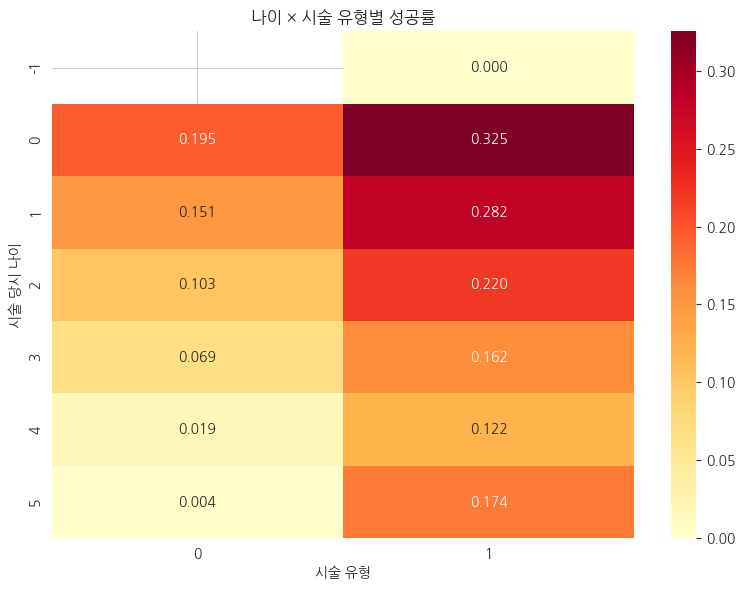

In [20]:
# 피벗 테이블: 나이 × 시술 유형별 성공률
pivot = train_copy.pivot_table(
    index='시술 당시 나이',
    columns='시술 유형',
    values=TARGET,
    aggfunc='mean'
)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd')
plt.title('나이 × 시술 유형별 성공률')
plt.tight_layout()
plt.show()

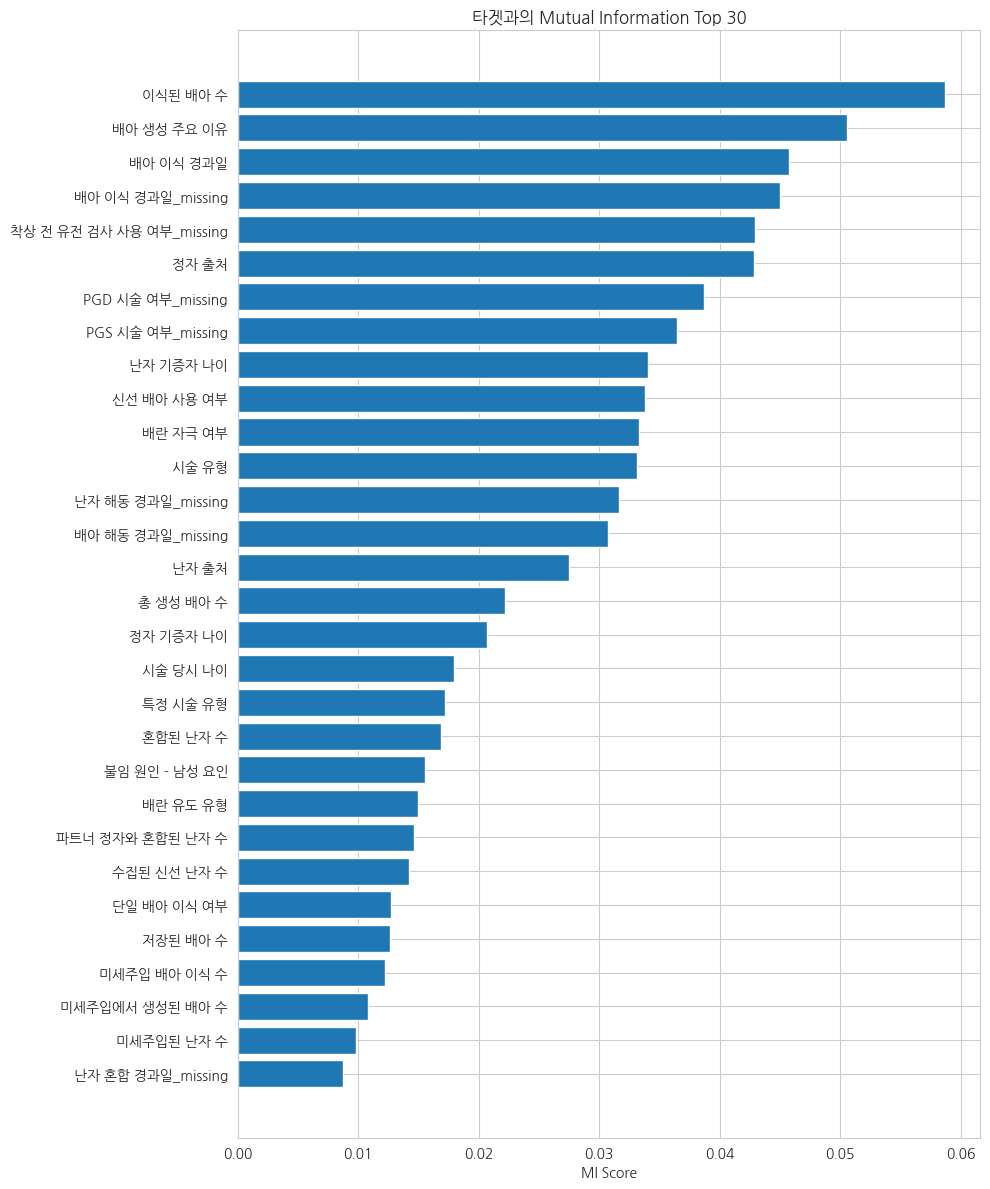

                     feature  mi_score
40                  이식된 배아 수  0.058654
26               배아 생성 주요 이유  0.050543
64                 배아 이식 경과일  0.045713
72         배아 이식 경과일_missing  0.044991
66  착상 전 유전 검사 사용 여부_missing  0.042956
52                     정자 출처  0.042813
67         PGD 시술 여부_missing  0.038647
68         PGS 시술 여부_missing  0.036416
53                 난자 기증자 나이  0.034071
56               신선 배아 사용 여부  0.033795
4                   배란 자극 여부  0.033258
2                      시술 유형  0.033151
69         난자 해동 경과일_missing  0.031618
73         배아 해동 경과일_missing  0.030759
51                     난자 출처  0.027477
37                 총 생성 배아 수  0.022194
54                 정자 기증자 나이  0.020660
1                   시술 당시 나이  0.017936
3                   특정 시술 유형  0.017204
48                  혼합된 난자 수  0.016832


In [21]:
from sklearn.feature_selection import mutual_info_classif

X = train_copy.drop(columns=['ID', TARGET])
y = train_copy[TARGET].astype(int)

# MI 계산 (시간 좀 걸림)
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({'feature': X.columns, 'mi_score': mi_scores})
mi_df = mi_df.sort_values('mi_score', ascending=False)

plt.figure(figsize=(10, 12))
plt.barh(mi_df['feature'][:30][::-1], mi_df['mi_score'][:30][::-1])
plt.title('타겟과의 Mutual Information Top 30')
plt.xlabel('MI Score')
plt.tight_layout()
plt.show()

print(mi_df.head(20))

<파생변수 생성 인사이트>

나이 젊을수록 성공률↑

출산경험 있으면 성공률↑

신선난자↑→ 배아수↑→ 성공률↑

혼합난자↑→ 배아수↑→ 성공률↑

이식 경과일 길수록 성공률↑

시술 횟수↑ → 성공률↓

정자/난자 본인 여부에 따른 성공 확률

In [17]:
# 파생변수 생성(260424)

def create_all_features(df):
    """
    파생변수 최종
    - 시각화 인사이트 기반 (나이/출산/효율/이식/이력)
    - 난자/정자 출처
    - 유용한 비율/효율 피처
    """
    df = df.copy()

    # 나이 구간
    df['고령_38이상']    = (df['시술 당시 나이'] >= 2).astype(int)
    df['고령_40이상']    = (df['시술 당시 나이'] >= 3).astype(int)
    df['초고령_43이상']  = (df['시술 당시 나이'] >= 4).astype(int)

    # 출산/임신 경험
    df['경산부']         = (df['총 출산 횟수'] > 0).astype(int)
    df['임신경험']       = (df['총 임신 횟수'] > 0).astype(int)
    df['유산경험_수']    = (df['총 임신 횟수'] - df['총 출산 횟수']).clip(lower=0)
    df['과거_시술성공률'] = df['총 출산 횟수'] / (df['총 시술 횟수'] + 1)

    # 난자 → 배아 효율
    df['신선난자_배아효율'] = df['총 생성 배아 수'] / (df['수집된 신선 난자 수'] + 1)
    df['신선난자_사용']    = (df['수집된 신선 난자 수'] > 0).astype(int)
    df['혼합난자_배아효율'] = df['총 생성 배아 수'] / (df['혼합된 난자 수'] + 1)
    df['난자_혼합률']     = df['혼합된 난자 수'] / (df['수집된 신선 난자 수'] + 1)
    df['파트너정자_비율']  = df['파트너 정자와 혼합된 난자 수'] / (df['혼합된 난자 수'] + 1)

    # 이식 관련
    df['이식_분할기']  = (df['배아 이식 경과일'].between(2, 3)).astype(int)
    df['이식_포배기']  = (df['배아 이식 경과일'] >= 5).astype(int)
    df['배양_기간']    = (df['배아 이식 경과일'] - df['난자 채취 경과일']).clip(lower=0)

    # 시술 이력
    df['반복실패_여부'] = ((df['총 시술 횟수'] >= 3) &
                        (df['총 출산 횟수'] == 0)).astype(int)
    df['실패경험_수']   = (df['총 시술 횟수'] - df['총 출산 횟수']).clip(lower=0)

    # 난자/정자 출처
    df['기증난자_사용'] = (df['난자 출처'] == 1).astype(int)
    df['기증정자_사용'] = (df['정자 출처'] == 1).astype(int)
    df['실효_난자_나이'] = np.where(
        (df['난자 출처'] == 1) & (df['난자 기증자 나이'] != -1),
        df['난자 기증자 나이'],
        df['시술 당시 나이']
    )
    df['고령_기증난자_상쇄'] = ((df['시술 당시 나이'] >= 3) &
                             (df['난자 출처'] == 1)).astype(int)

    # 배아/난자 파이프라인 효율
    df['이식_비율']    = df['이식된 배아 수'] / (df['총 생성 배아 수'] + 1)
    df['배아_여유']    = df['저장된 배아 수'] / (df['총 생성 배아 수'] + 1)
    df['파이프_효율']  = df['이식된 배아 수'] / (df['수집된 신선 난자 수'] + 1)
    df['배아_손실수']  = (df['총 생성 배아 수'] - df['이식된 배아 수']).clip(lower=0)


    # 시술 방식/진행 시간 간격
    df['혼합_이식_간격']    = (df['배아 이식 경과일'] - df['난자 혼합 경과일']).abs()
    df['해동_이식_간격']    = (df['배아 이식 경과일'] - df['배아 해동 경과일']).abs()
    df['난자해동_혼합_간격'] = (df['난자 혼합 경과일'] - df['난자 해동 경과일']).abs()


    return df



# 적용


# 이전에 쓸모없는 피처가 이미 들어갔으면 먼저 제거
useless_cols = [
    '배아수_x_실효나이', '배아수_x_기증난자', '이식_배아_0', '이식_배아_2이상',
    '이식_0개', '이식_1개', '이식_2개', '이식_3개이상',
    '배아x나이', '배아x기증', '시술x나이', '시술x배아','신선_사이클',
    '동결난자_사이클', '동결배아_이식', '채취_혼합_간격', '사이클_복합도'
]
for c in useless_cols:
    if c in train_copy.columns:
        train_copy = train_copy.drop(columns=c)
    if c in test_copy.columns:
        test_copy = test_copy.drop(columns=c)

# 혹시 이미 create_all_features가 적용된 상태라면, 원본에서 다시 시작
# (이미 만든 피처를 또 만들면 에러는 없지만 안전하게 재생성)
train_copy = create_all_features(train_copy)
test_copy  = create_all_features(test_copy)

print(f"✅ 최종 Train shape: {train_copy.shape}")
print(f"✅ 최종 Test shape:  {test_copy.shape}")
print(f"\n신규 피처 목록:")
new_features = ['고령_38이상', '고령_40이상', '초고령_43이상',
                '경산부', '임신경험', '유산경험_수', '과거_시술성공률',
                '신선난자_배아효율', '신선난자_사용', '혼합난자_배아효율',
                '난자_혼합률', '파트너정자_비율',
                '이식_분할기', '이식_포배기', '배양_기간',
                '반복실패_여부', '실패경험_수',
                '기증난자_사용', '기증정자_사용', '실효_난자_나이', '고령_기증난자_상쇄',
                '이식_비율', '배아_여유', '파이프_효율', '배아_손실수',
                '혼합_이식_간격','해동_이식_간격','난자해동_혼합_간격']
print(f"총 {len(new_features)}개")
for f in new_features:
    print(f"  - {f}")

✅ 최종 Train shape: (256351, 104)
✅ 최종 Test shape:  (90067, 103)

신규 피처 목록:
총 28개
  - 고령_38이상
  - 고령_40이상
  - 초고령_43이상
  - 경산부
  - 임신경험
  - 유산경험_수
  - 과거_시술성공률
  - 신선난자_배아효율
  - 신선난자_사용
  - 혼합난자_배아효율
  - 난자_혼합률
  - 파트너정자_비율
  - 이식_분할기
  - 이식_포배기
  - 배양_기간
  - 반복실패_여부
  - 실패경험_수
  - 기증난자_사용
  - 기증정자_사용
  - 실효_난자_나이
  - 고령_기증난자_상쇄
  - 이식_비율
  - 배아_여유
  - 파이프_효율
  - 배아_손실수
  - 혼합_이식_간격
  - 해동_이식_간격
  - 난자해동_혼합_간격


In [18]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00


In [19]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.3 MB/s eta 0:00:00


In [21]:
# !pip install optuna -q

import optuna
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

optuna.logging.set_verbosity(optuna.logging.WARNING)

X = train_copy.drop(columns=['ID', '임신 성공 여부'])
y = train_copy['임신 성공 여부']
X_test = test_copy.drop(columns=['ID'])

def objective(trial):
    params = {
        'iterations': 1500,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08, log=True),
        'depth': trial.suggest_int('depth', 5, 9),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 30),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength': trial.suggest_float('random_strength', 0.0, 2.0),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'random_seed': 42,
        'eval_metric': 'AUC',
        'early_stopping_rounds': 50,
        'verbose': False
    }

    # 속도 위해 3-fold만 사용
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    aucs = []
    for tr_idx, val_idx in skf.split(X, y):
        m = CatBoostClassifier(**params)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx],
              eval_set=(X.iloc[val_idx], y.iloc[val_idx]))
        prob = m.predict_proba(X.iloc[val_idx])[:, 1]
        aucs.append(roc_auc_score(y.iloc[val_idx], prob))

    return np.mean(aucs)

# 30번 시도
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\nBest AUC: {study.best_value:.4f}")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"   {k}: {v}")

  0%|          | 0/30 [00:00<?, ?it/s]


Best AUC: 0.7398
Best params:
   learning_rate: 0.010402169777212351
   depth: 8
   l2_leaf_reg: 7.35932864462546
   min_data_in_leaf: 18
   bagging_temperature: 0.6527836420072781
   random_strength: 1.7526579808481118
   border_count: 121


In [22]:
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

# Optuna에서 찾은 최적 파라미터
best_params = {
    'learning_rate': 0.010402169777212351,
    'depth': 8,
    'l2_leaf_reg': 7.35932864462546,
    'min_data_in_leaf': 18,
    'bagging_temperature': 0.6527836420072781,
    'random_strength': 1.7526579808481118,
    'border_count': 121,
    'iterations': 3000,              # learning_rate 낮아서 더 많이 필요
    'eval_metric': 'AUC',
    'early_stopping_rounds': 150,    # 여유 있게
    'verbose': False
}

X = train_copy.drop(columns=['ID', '임신 성공 여부'])
y = train_copy['임신 성공 여부']
X_test = test_copy.drop(columns=['ID'])

# 3-seed × 5-fold
seeds = [42, 99, 2024]
tuned_test = np.zeros(len(X_test))
tuned_oof = np.zeros(len(X))

for seed in seeds:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    seed_aucs = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        params = best_params.copy()
        params['random_seed'] = seed

        m = CatBoostClassifier(**params)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx],
              eval_set=(X.iloc[val_idx], y.iloc[val_idx]))

        val_prob = m.predict_proba(X.iloc[val_idx])[:, 1]
        tuned_oof[val_idx] += val_prob / len(seeds)
        tuned_test += m.predict_proba(X_test)[:, 1] / (5 * len(seeds))

        auc = roc_auc_score(y.iloc[val_idx], val_prob)
        seed_aucs.append(auc)

    print(f"Seed {seed} 평균: {np.mean(seed_aucs):.4f}")

print(f"\n▶ 튜닝 최종 OOF AUC: {roc_auc_score(y, tuned_oof):.4f}")
print(f"▶ 이전 최고 OOF:      0.7403")

Seed 42 평균: 0.7402
Seed 99 평균: 0.7401
Seed 2024 평균: 0.7403

▶ 튜닝 최종 OOF AUC: 0.7404
▶ 이전 최고 OOF:      0.7403


In [24]:
import pandas as pd

sample_sub = pd.read_csv('sample_submission.csv')

submission = pd.DataFrame({
    'ID': test_copy['ID'],
    'probability': tuned_test
})
submission = sample_sub[['ID']].merge(submission, on='ID', how='left')
submission.to_csv('submission_final_tuned.csv', index=False)

print("✅ 최종 제출 파일 생성!")
print(submission.head())
print(f"\n총 {len(submission):,}행")
print(f"probability 분포:\n{submission['probability'].describe()}")

✅ 최종 제출 파일 생성!
           ID  probability
0  TEST_00000     0.001750
1  TEST_00001     0.010637
2  TEST_00002     0.146407
3  TEST_00003     0.113102
4  TEST_00004     0.504828

총 90,067행
probability 분포:
count    90067.000000
mean         0.258235
std          0.159458
min          0.000155
25%          0.143661
50%          0.269226
75%          0.378453
max          0.772742
Name: probability, dtype: float64
